# Lab 4 — Dashboard ejecutivo: de datos a historia (hands-on)

**Modalidad:** hands-on · **Duración:** ~12 min

## Objetivo
Construir una tabla resumen (1 página, 4 secciones) que un director pueda leer en 60 segundos. Practicar el principio **"una cifra, una historia"**.

## Estructura del reporte
1. **Disponibilidad y SLOs** — error budget consumido, top 3 incidentes.
2. **Automatización** — success rate global, job con peor MTTR, retries.
3. **Demanda operativa** — tickets/día, breach SLA por equipo, rollback.
4. **Recomendaciones** — 3 acciones priorizadas (RICE simple).

## Plantilla
Las celdas ya están armadas — solo tienes que conectar los datos correctos.

## 0. Carga + limpieza mínima

**Qué hacemos:** una sola pasada de limpieza para que las 4 secciones siguientes trabajen sobre datos coherentes.

**Por qué centralizada:** aplicamos el mismo criterio que aprendimos en los labs anteriores.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

DATA = Path('..') / 'data'
metrics = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])
incidents = pd.read_csv(DATA / 'incidents.csv', parse_dates=['opened_at', 'resolved_at'])
burn = pd.read_csv(DATA / 'slo_burn.csv', parse_dates=['ts'])
runs = pd.read_csv(DATA / 'automation_runs.csv', parse_dates=['started_at'])
tickets = pd.read_csv(DATA / 'tickets.csv', parse_dates=['created_at'])

In [2]:
# ==== Limpieza minima necesaria para el dashboard ====
# metrics: drop errores tecnicos + imputar mediana en numericas
for col, lo, hi in [('latency_ms', 0, 10_000), ('cpu_pct', 0, 100)]:
    metrics = metrics.loc[~((metrics[col] < lo) | (metrics[col] > hi))].copy()
    metrics[col] = metrics[col].fillna(metrics[col].median())
# runs: drop duraciones imposibles
runs = runs.loc[~((runs['duration_sec'] < 0) | (runs['duration_sec'] > 86400))].copy()
# tickets: drop errores tecnicos y rellenar priority/team NaN
tickets = tickets.loc[~((tickets['resolution_min'] <= 0) | (tickets['resolution_min'] > 100_000))].copy()
tickets['priority'] = tickets['priority'].fillna(tickets['priority'].mode().iloc[0])
tickets['team'] = tickets['team'].fillna(tickets['team'].mode().iloc[0])
print('Listo: shapes ->', metrics.shape, runs.shape, tickets.shape)

Listo: shapes -> (965210, 9) (1472, 8) (893, 9)


## 1) Disponibilidad y SLOs

**Qué reportamos al director:** disponibilidad observada en el periodo + top 3 incidentes por clientes afectados + burn-rate medio.

Disponibilidad observada: 99.7677%
Burn-rate 5x medio en incidentes: 2.32x


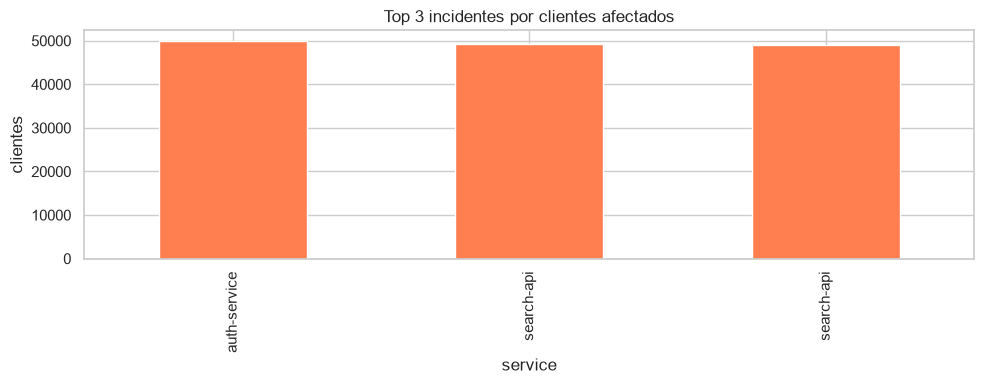

In [3]:
avail = 1 - metrics['error_rate'].mean()
burn_max = burn.groupby('incident_id')['burn_5x'].max().mean()
print(f'Disponibilidad observada: {avail:.4%}')
print(f'Burn-rate 5x medio en incidentes: {burn_max:.2f}x')
fig, ax = plt.subplots(figsize=(10, 4))
top3 = incidents.nlargest(3, 'customers_affected')[['service', 'customers_affected', 'mttr_min']]
top3.set_index('service')['customers_affected'].plot(kind='bar', color='coral', ax=ax)
ax.set_title('Top 3 incidentes por clientes afectados')
ax.set_ylabel('clientes')
plt.tight_layout()
plt.savefig('../html/lab4_fig1_avail.png', dpi=110, bbox_inches='tight')
plt.show()

## 2) Automatización

**Qué reportamos:** success rate global + job con peor MTTR en fallos.

Success rate global: 87.77%
Job con peor MTTR:
job_name
failover_drill    73.0
Name: duration_sec, dtype: float64



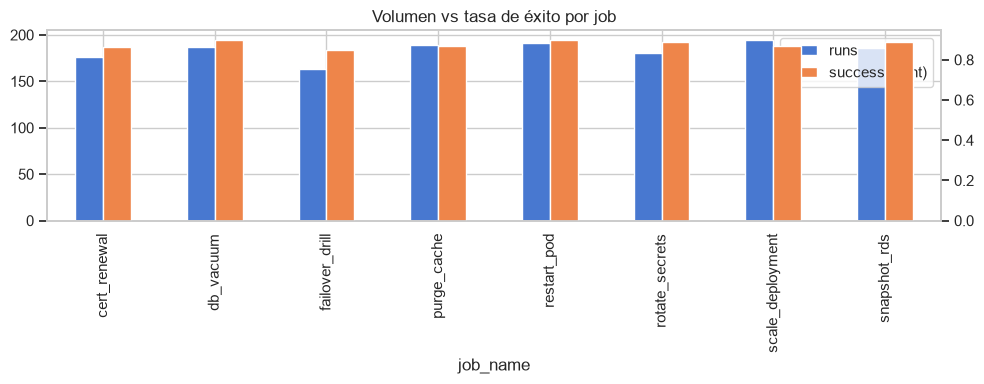

In [4]:
auto_ok = (runs['status'] == 'success').mean()
failed = runs[runs['status'].isin(['failed','timeout'])]
worst_job = failed.groupby('job_name')['duration_sec'].median().sort_values(ascending=False).head(1)
print(f'Success rate global: {auto_ok:.2%}')
print(f'Job con peor MTTR:\n{worst_job}\n')
fig, ax = plt.subplots(figsize=(10, 4))
agg = runs.groupby('job_name').agg(
    runs=('run_id', 'count'),
    success=('status', lambda s: (s == 'success').mean()),
)
agg.plot(kind='bar', secondary_y='success', ax=ax)
ax.set_title('Volumen vs tasa de éxito por job')
plt.tight_layout()
plt.savefig('../html/lab4_fig2_auto.png', dpi=110, bbox_inches='tight')
plt.show()

## 3) Demanda operativa

**Qué reportamos:** tickets por día en promedio + equipo líder en breach + rollback rate.

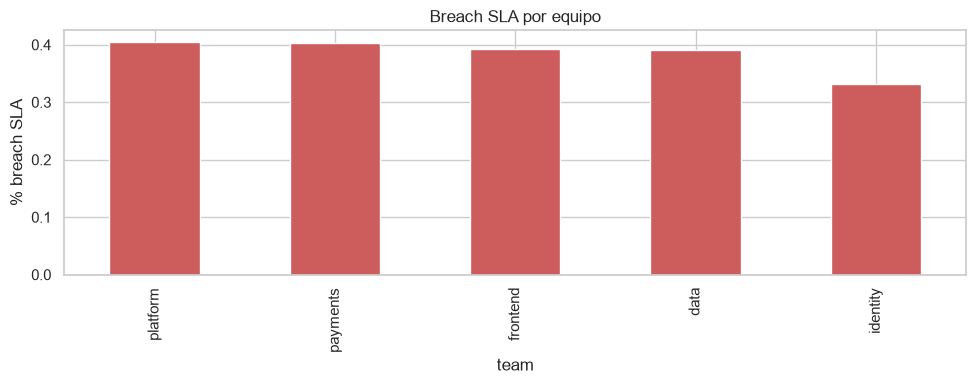

Tickets/día promedio: 19.8
Rollback rate (changes): 10.17%


In [5]:
tickets['date'] = tickets['created_at'].dt.date
vol = tickets.groupby('date').size().mean()
rollback_rate = tickets.loc[tickets['category']=='change', 'rollback'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
tickets.groupby('team')['sla_breached'].mean().sort_values(ascending=False).plot(kind='bar', color='indianred', ax=ax)
ax.set_ylabel('% breach SLA')
ax.set_title('Breach SLA por equipo')
plt.tight_layout()
plt.savefig('../html/lab4_fig3_ops.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'Tickets/día promedio: {vol:.1f}')
print(f'Rollback rate (changes): {rollback_rate:.2%}')

## 4) Recomendaciones (RICE simplificado)

**Qué es RICE:** Reach × Impact / Effort. Prioriza donde el beneficio (alcance × impacto) supera el esfuerzo.

**Por qué importa:** convierte hallazgos en acciones comparables.

In [6]:
# Cambia las 3 acciones según los hallazgos de tu dupla
recos = pd.DataFrame([
    {'accion': 'Reducir p95 de checkout-api', 'reach': 8, 'impact': 3, 'effort': 2},
    {'accion': 'Automatizar retry de db_vacuum', 'reach': 6, 'impact': 2, 'effort': 1},
    {'accion': 'Repriorizar P1 del equipo payments', 'reach': 5, 'impact': 3, 'effort': 1},
])
recos['rice'] = recos['reach'] * recos['impact'] / recos['effort']
recos.sort_values('rice', ascending=False)

,accion,reach,impact,effort,rice
2,Repriorizar P1 del equipo payments,5,3,1,15.0
0,Reducir p95 de checkout-api,8,3,2,12.0
1,Automatizar retry de db_vacuum,6,2,1,12.0


## Headline — escribe 1 línea por sección

**Regla:** 1 cifra grande + 1 responsable + 1 ventana de tiempo + 1 acción priorizada.

**Ejemplo:**
> "Disponibilidad del 99.92 %; el servicio checkout-api explica el 60 % del error budget consumido en los últimos 30 días."